<a href="https://colab.research.google.com/github/manchalaharika2007-commits/CodeAlpha-Tasks/blob/main/Task1_Web%20Scraping/task1_web_scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

In [ ]:
import requests

url = "https://books.toscrape.com/"

response = requests.get(url)

print("Status Code:", response.status_code)

Status Code: 200


In [ ]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [ ]:
books = soup.find_all("article", class_="product_pod")

print("Number of books found:", len(books))

Number of books found: 20


In [ ]:
print(books[0].prettify())

<article class="product_pod">
 <div class="image_container">
  <a href="catalogue/a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
 </p>
 <h3>
  <a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">
   A Light in the ...
  </a>
 </h3>
 <div class="product_price">
  <p class="price_color">
   Â£51.77
  </p>
  <p class="instock availability">
   <i class="icon-ok">
   </i>
   In stock
  </p>
  <form>
   <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">
    Add to basket
   </button>
  </form>
 </div>
</article>



In [ ]:
title = books[0].h3.a["title"]

print("Book Title:", title)

Book Title: A Light in the Attic


In [ ]:
price = books[0].find("p", class_="price_color").text

print("Book Price:", price)

Book Price: Â£51.77


In [ ]:
availability = books[0].find(
    "p",
    class_="instock availability"
).text.strip()

print("Availability:", availability)

Availability: In stock


In [ ]:
rating = books[0].find("p", class_="star-rating")["class"][1]

print("Rating:", rating)

Rating: Three


In [ ]:
book_url = books[0].h3.a["href"]

print("Book URL:", book_url)

Book URL: catalogue/a-light-in-the-attic_1000/index.html


In [ ]:
data = []

for book in books:

    # Extract title
    title = book.h3.a["title"]

    # Extract price
    price = book.find(
        "p",
        class_="price_color"
    ).text.strip()

    # Extract availability
    availability = book.find(
        "p",
        class_="instock availability"
    ).text.strip()

    # Extract rating
    rating = book.find(
        "p",
        class_="star-rating"
    )["class"][1]

    # Extract URL
    book_url = book.h3.a["href"]

    # Convert relative URL to complete URL
    book_url = "https://books.toscrape.com/" + book_url

    # Store everything
    data.append({
        "Title": title,
        "Price": price,
        "Rating": rating,
        "Availability": availability,
        "URL": book_url
    })

print("Total books scraped:", len(data))

Total books scraped: 20


In [ ]:
all_books = []

base_url = "https://books.toscrape.com/catalogue/page-{}.html"

for page in range(1, 6):

    url = base_url.format(page)

    response = requests.get(url)

    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.find_all(
        "article",
        class_="product_pod"
    )

    print(f"Page {page}: {len(books)} books found")

    for book in books:

        title = book.h3.a["title"]

        price = book.find(
            "p",
            class_="price_color"
        ).text.strip()

        availability = book.find(
            "p",
            class_="instock availability"
        ).text.strip()

        rating = book.find(
            "p",
            class_="star-rating"
        )["class"][1]

        book_url = book.h3.a["href"]

        # Convert relative URL into complete URL
        book_url = "https://books.toscrape.com/catalogue/" + book_url

        all_books.append({
            "Title": title,
            "Price": price,
            "Rating": rating,
            "Availability": availability,
            "URL": book_url
        })

    # Small delay between requests
    time.sleep(1)

print("\nTotal books scraped:", len(all_books))

Page 1: 20 books found
Page 2: 20 books found
Page 3: 20 books found
Page 4: 20 books found
Page 5: 20 books found

Total books scraped: 100


In [ ]:
df = pd.DataFrame(all_books)

print("Dataset created successfully!")
print("Shape:", df.shape)

Dataset created successfully!
Shape: (100, 5)


In [ ]:
df.head(10)

,Title,Price,Rating,Availability,URL
0,A Light in the Attic,Â£51.77,Three,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,One,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,One,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,Four,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,https://books.toscrape.com/catalogue/sapiens-a...
5,The Requiem Red,Â£22.65,One,In stock,https://books.toscrape.com/catalogue/the-requi...
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,Four,In stock,https://books.toscrape.com/catalogue/the-dirty...
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,Three,In stock,https://books.toscrape.com/catalogue/the-comin...
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,Four,In stock,https://books.toscrape.com/catalogue/the-boys-...
9,The Black Maria,Â£52.15,One,In stock,https://books.toscrape.com/catalogue/the-black...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         100 non-null    object
 1   Price         100 non-null    object
 2   Rating        100 non-null    object
 3   Availability  100 non-null    object
 4   URL           100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Title           0
Price           0
Rating          0
Availability    0
URL             0
dtype: int64


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df["Price"] = (
    df["Price"]
    .str.replace("Â£", "", regex=False)
    .astype(float)
)

print(df["Price"].head())

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price, dtype: float64


In [ ]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

print(df["Rating"].head())

0    3
1    1
2    1
3    4
4    5
Name: Rating, dtype: int64


In [ ]:
print(df.dtypes)

Title            object
Price           float64
Rating            int64
Availability     object
URL              object
dtype: object


In [ ]:
display(df.head(10))

,Title,Price,Rating,Availability,URL
0,A Light in the Attic,51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...
5,The Requiem Red,22.65,1,In stock,https://books.toscrape.com/catalogue/the-requi...
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,In stock,https://books.toscrape.com/catalogue/the-dirty...
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,In stock,https://books.toscrape.com/catalogue/the-comin...
8,The Boys in the Boat: Nine Americans and Their...,22.60,4,In stock,https://books.toscrape.com/catalogue/the-boys-...
9,The Black Maria,52.15,1,In stock,https://books.toscrape.com/catalogue/the-black...


In [ ]:
print("Total number of books:", len(df))

Total number of books: 100


In [ ]:
average_price = df["Price"].mean()

print("Average book price: £", round(average_price, 2))

Average book price: £ 34.56


In [ ]:
cheapest_book = df.loc[df["Price"].idxmin()]

print("Cheapest Book:")
print("Title:", cheapest_book["Title"])
print("Price: £", cheapest_book["Price"])

Cheapest Book:
Title: Patience
Price: £ 10.16


In [ ]:
expensive_book = df.loc[df["Price"].idxmax()]

print("Most Expensive Book:")
print("Title:", expensive_book["Title"])
print("Price: £", expensive_book["Price"])

Most Expensive Book:
Title: The Death of Humanity: and the Case for Life
Price: £ 58.11


In [ ]:
average_rating = df["Rating"].mean()

print("Average Rating:", round(average_rating, 2))

Average Rating: 2.93


In [ ]:
rating_counts = df["Rating"].value_counts().sort_index()

print(rating_counts)

Rating
1    22
2    19
3    22
4    18
5    19
Name: count, dtype: int64


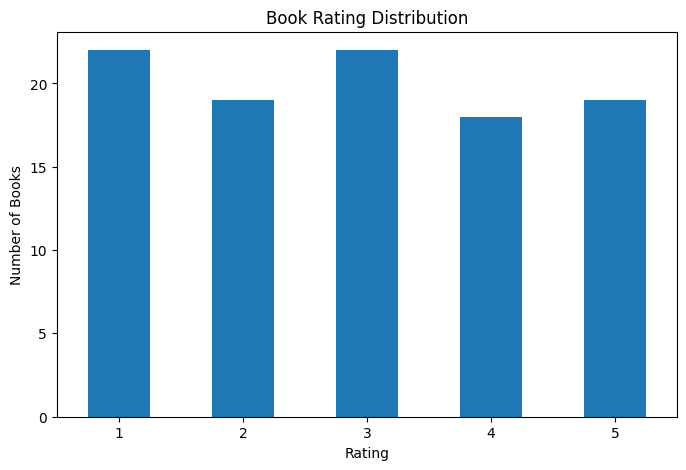

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

rating_counts.plot(
    kind="bar"
)

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.xticks(rotation=0)

plt.show()

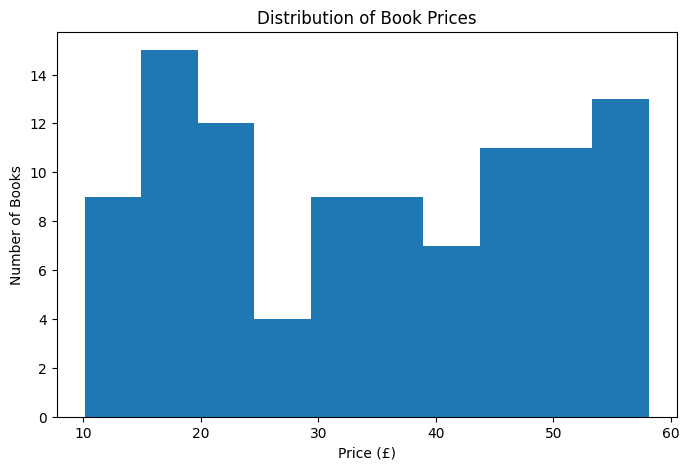

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Price"],
    bins=10
)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.show()

In [ ]:
top_10_expensive = df.sort_values(
    "Price",
    ascending=False
).head(10)

display(
    top_10_expensive[
        ["Title", "Price", "Rating"]
    ]
)

,Title,Price,Rating
68,The Death of Humanity: and the Case for Life,58.11,4
40,Slow States of Collapse: Poems,57.31,3
15,Our Band Could Be Your Life: Scenes from the A...,57.25,3
58,The Past Never Ends,56.50,4
57,The Pioneer Woman Cooks: Dinnertime: Comfort C...,56.41,1
91,Masks and Shadows,56.40,2
56,The Secret of Dreadwillow Carse,56.13,1
67,The Electric Pencil: Drawings from Inside Stat...,56.06,1
25,Birdsong: A Story in Pictures,54.64,3
4,Sapiens: A Brief History of Humankind,54.23,5


In [ ]:
df.to_csv(
    "books_scraped_cleaned.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
from google.colab import files

files.download("books_scraped_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Page 1: 20 books found
Page 2: 20 books found
Page 3: 20 books found
Page 4: 20 books found
Page 5: 20 books found

===== DATASET SUMMARY =====
Total books: 100
Average price: £ 34.56
Average rating: 2.93
Minimum price: £ 10.16
Maximum price: £ 58.11

===== RATING DISTRIBUTION =====
Rating
1    22
2    19
3    22
4    18
5    19
Name: count, dtype: int64


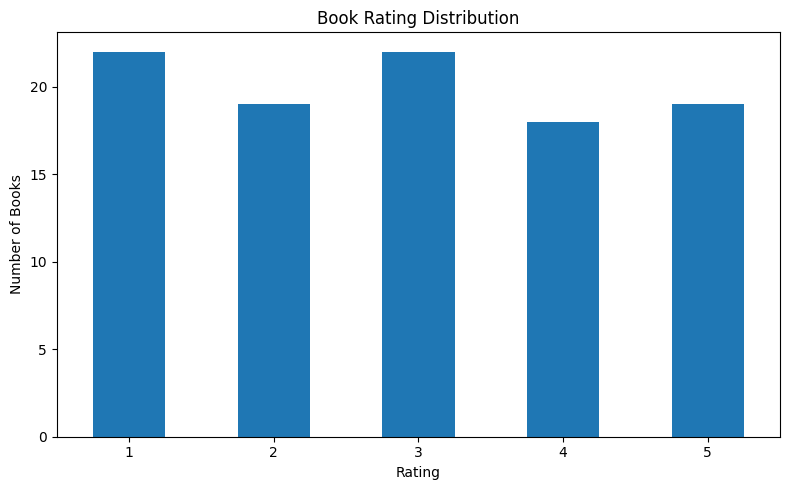

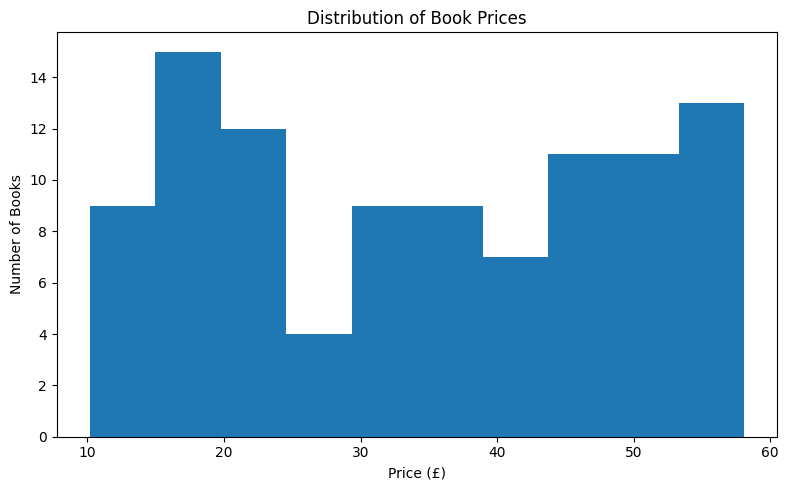


===== TOP 10 EXPENSIVE BOOKS =====
                                                                                                                          Title  Price  Rating
                                                                                   The Death of Humanity: and the Case for Life  58.11       4
                                                                                                 Slow States of Collapse: Poems  57.31       3
                                             Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991  57.25       3
                                                                                                            The Past Never Ends  56.50       4
The Pioneer Woman Cooks: Dinnertime: Comfort Classics, Freezer Food, 16-Minute Meals, and Other Delicious Ways to Solve Supper!  56.41       1
                                                                                                          

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import matplotlib.pyplot as plt


# ============================================
# WEB SCRAPING - BOOKS TO SCRAPE
# ============================================

all_books = []

base_url = "https://books.toscrape.com/catalogue/page-{}.html"


# ============================================
# SCRAPE 5 PAGES
# ============================================

for page in range(1, 6):

    url = base_url.format(page)

    response = requests.get(url)

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    books = soup.find_all(
        "article",
        class_="product_pod"
    )

    print(
        f"Page {page}: {len(books)} books found"
    )

    for book in books:

        # Book title
        title = book.h3.a["title"]

        # Book price
        price = book.find(
            "p",
            class_="price_color"
        ).text.strip()

        # Availability
        availability = book.find(
            "p",
            class_="instock availability"
        ).text.strip()

        # Rating
        rating = book.find(
            "p",
            class_="star-rating"
        )["class"][1]

        # Book URL
        book_url = book.h3.a["href"]

        book_url = (
            "https://books.toscrape.com/catalogue/"
            + book_url
        )

        all_books.append({
            "Title": title,
            "Price": price,
            "Rating": rating,
            "Availability": availability,
            "URL": book_url
        })

    time.sleep(1)


# ============================================
# CREATE DATAFRAME
# ============================================

df = pd.DataFrame(all_books)


# ============================================
# DATA CLEANING
# ============================================

df["Price"] = (
    df["Price"]
    .str.replace("Â£", "", regex=False)
    .astype(float)
)


rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)


# ============================================
# BASIC ANALYSIS
# ============================================

print("\n===== DATASET SUMMARY =====")

print(
    "Total books:",
    len(df)
)

print(
    "Average price: £",
    round(df["Price"].mean(), 2)
)

print(
    "Average rating:",
    round(df["Rating"].mean(), 2)
)

print(
    "Minimum price: £",
    df["Price"].min()
)

print(
    "Maximum price: £",
    df["Price"].max()
)


# ============================================
# RATING DISTRIBUTION
# ============================================

rating_counts = (
    df["Rating"]
    .value_counts()
    .sort_index()
)

print("\n===== RATING DISTRIBUTION =====")

print(rating_counts)


plt.figure(figsize=(8, 5))

rating_counts.plot(
    kind="bar"
)

plt.title(
    "Book Rating Distribution"
)

plt.xlabel("Rating")

plt.ylabel(
    "Number of Books"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "rating_distribution.png"
)

plt.show()


# ============================================
# PRICE DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

plt.hist(
    df["Price"],
    bins=10
)

plt.title(
    "Distribution of Book Prices"
)

plt.xlabel(
    "Price (£)"
)

plt.ylabel(
    "Number of Books"
)

plt.tight_layout()

plt.savefig(
    "price_distribution.png"
)

plt.show()


# ============================================
# TOP 10 EXPENSIVE BOOKS
# ============================================

top_10 = (
    df.sort_values(
        "Price",
        ascending=False
    )
    .head(10)
)

print(
    "\n===== TOP 10 EXPENSIVE BOOKS ====="
)

print(
    top_10[
        ["Title", "Price", "Rating"]
    ].to_string(index=False)
)


# ============================================
# SAVE DATASET
# ============================================

df.to_csv(
    "books_scraped_cleaned.csv",
    index=False
)

print(
    "\nDataset saved as "
    "books_scraped_cleaned.csv"
)


In [ ]:
from google.colab import files

files.download("books_scraped_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("rating_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("price_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>